**Author:** Biswajit Jana
**Date:** August 4, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-uncover-spatial-selection/notebook.ipynb)

# Is the sky density of UNCOVER high-z candidates spatially uniform?

**Scientific question:** Do candidate surface-density variations track F444W coverage and lensing structure?


This notebook uses the frozen UNCOVER DR3 “SUPER” photometric catalogue for
Abell 2744. The release combines HST and JWST imaging, detects sources in a
noise-equalized F277W+F356W+F444W image, PSF-matches the photometry to F444W,
and supplies EAzY photometric-redshift posteriors. The compact repository table
contains rows with usable photometry, a passing EAzY flag, and a maximum-
likelihood redshift from 6 to 15.

That is a candidate selection, not a confirmation list. A photometric redshift
can confuse a Lyman break with dust, an emission-line boosted band, or a lower-
redshift spectral break. Abell 2744 also lenses the background and changes both
the observed brightness and the effective source-plane area. Every result below
is therefore conditional on the release photometry, templates, flags, and lens
model. The notebook measures the catalogue; it does not claim a new population
measurement or spectroscopic discovery.

## Reproducibility contract

The source is Zenodo DOI `10.5281/zenodo.11059273`, retrieved on 1 August 2026.
The upstream FITS MD5 is `baeb44ce166c920050ceb93220b12e05`. The repository
derivative preserves coordinates, broad-band fluxes and errors, redshift
posterior percentiles, flags, an image size proxy, and lensing magnification.
Fluxes are in the catalogue's native 10 nJy units (AB zeropoint 28.9). We keep
negative flux measurements when summarising stacks because clipping them would
bias faint measurements upward. Each figure is saved at publication-oriented
resolution with SciencePlots' `science` style and `no-latex` for reliable Colab
execution.

## Claim boundary

The analysis distinguishes observed quantities from derived proxies. It reports
sample sizes, selection changes, resampling intervals, or parameter stress
tests. Results may motivate a targeted check against UNCOVER DR4 spectroscopy,
but the photometric catalogue alone cannot prove a galaxy's redshift, stellar
mass, star-formation rate, chemical abundance, or physical size. Those require
spectroscopy and/or more complete forward modelling with selection functions.

## Selection-map question

Deep fields are not uniformly sensitive. The Abell 2744 mosaic combines
programs, has spatially varying weight, contains subtracted cluster galaxies,
and samples a strong lens. We bin the candidate coordinates into a 7-by-7 sky
grid, count candidates, and record median F444W weight and magnification per
occupied cell. A Spearman correlation tests whether cells with deeper F444W
coverage contain more selected candidates. This does not measure cosmic
clustering because the denominator—the number of all detectable galaxies in
each cell—and the source-plane area are absent. It is a diagnostic of why a
sky map should accompany any population claim.

In [1]:
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

plt.style.use(["science", "no-latex"])
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 220, "axes.titleweight": "bold"})
COLORS = {"navy": "#071426", "cyan": "#39c6d4", "gold": "#e3a82b",
          "coral": "#e66b55", "violet": "#7357c7", "green": "#3b9b77"}
RNG = np.random.default_rng(1999)

In [2]:
LOCAL = Path("../../data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv")
RAW = "https://raw.githubusercontent.com/Biswajit1999/daily-astro-notebooks/master/data/uncover_dr3_highz/uncover_dr3_z6_candidates.csv"
if not LOCAL.exists():
    LOCAL = Path("uncover_dr3_z6_candidates.csv")
    if not LOCAL.exists():
        urllib.request.urlretrieve(RAW, LOCAL)
data = pd.read_csv(LOCAL)
print(f"Loaded {len(data):,} quality-flagged photometric candidates")
print(f"Sky footprint: RA {data.ra.min():.4f}–{data.ra.max():.4f} deg; Dec {data.dec.min():.4f}–{data.dec.max():.4f} deg")

Loaded 4,731 quality-flagged photometric candidates
Sky footprint: RA 3.4448–3.6699 deg; Dec -30.4673–-30.2914 deg


In [3]:
spatial=data[np.isfinite(data.ra)&np.isfinite(data.dec)&np.isfinite(data.w_f444w)&np.isfinite(data.mu)].copy()
ra_edges=np.linspace(spatial.ra.min(),spatial.ra.max(),8); dec_edges=np.linspace(spatial.dec.min(),spatial.dec.max(),8)
spatial["ra_bin"]=pd.cut(spatial.ra,ra_edges,labels=False,include_lowest=True)
spatial["dec_bin"]=pd.cut(spatial.dec,dec_edges,labels=False,include_lowest=True)
grid=spatial.groupby(["ra_bin","dec_bin"],observed=True).agg(candidate_count=("id","size"),median_f444w_weight=("w_f444w","median"),median_mu=("mu","median"),median_z=("z_phot","median")).reset_index()
grid.to_csv("spatial_grid_summary.csv",index=False)
rho,p=stats.spearmanr(grid.candidate_count,grid.median_f444w_weight,nan_policy="omit")
print(f"Occupied cells={len(grid)}; density-depth Spearman rho={rho:.3f}, p={p:.3g}")

Occupied cells=34; density-depth Spearman rho=0.424, p=0.0125


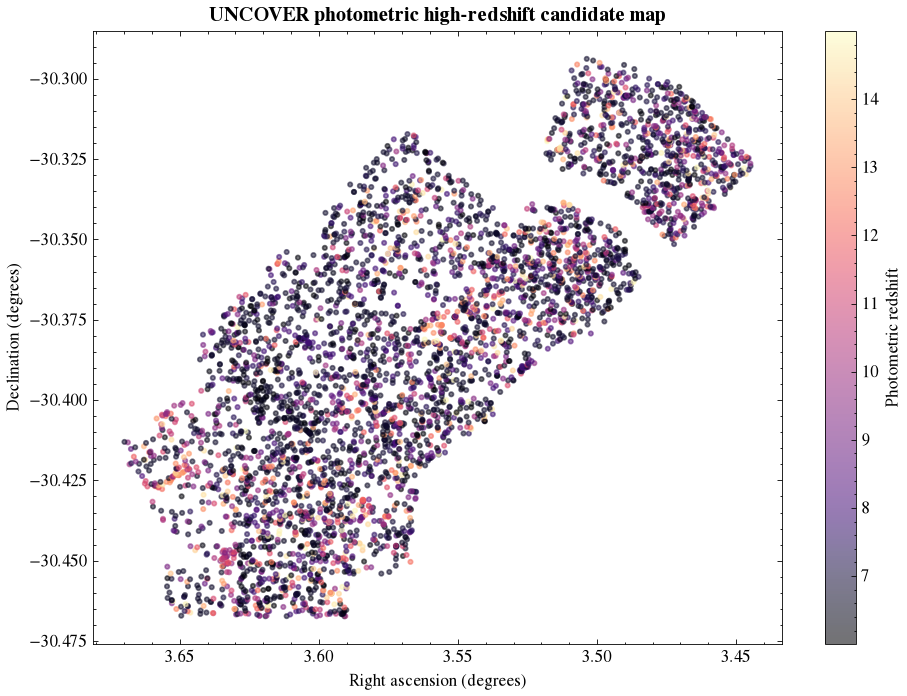

In [4]:
fig,ax=plt.subplots(figsize=(8.2,6)); sc=ax.scatter(spatial.ra,spatial.dec,c=spatial.z_phot,s=7,cmap="magma",alpha=.55,rasterized=True)
ax.invert_xaxis(); ax.set(xlabel="Right ascension (degrees)",ylabel="Declination (degrees)",title="UNCOVER photometric high-redshift candidate map")
fig.colorbar(sc,ax=ax,label="Photometric redshift"); fig.tight_layout(); fig.savefig("highz_candidate_sky_map.png"); plt.show()

## Depth relation and null interpretation

The grid correlation is reported with its p-value but is not treated as a
formal discovery test: adjacent cells share observing strategy and lensing
structure, grid choice is arbitrary, and candidate counts are not independent.
We repeat the correlation for 5-, 6-, 7-, 8-, and 9-bin grids. A changing sign
or magnitude would warn that the headline coefficient is mostly a binning
artifact.

In [5]:
stress=[]
for nbin in [5,6,7,8,9]:
    rb=pd.cut(spatial.ra,np.linspace(spatial.ra.min(),spatial.ra.max(),nbin+1),labels=False,include_lowest=True)
    db=pd.cut(spatial.dec,np.linspace(spatial.dec.min(),spatial.dec.max(),nbin+1),labels=False,include_lowest=True)
    g=spatial.assign(rb=rb,db=db).groupby(["rb","db"],observed=True).agg(count=("id","size"),weight=("w_f444w","median"),mu=("mu","median")).reset_index()
    rr,pp=stats.spearmanr(g["count"],g.weight,nan_policy="omit"); rm,pm=stats.spearmanr(g["count"],g.mu,nan_policy="omit")
    stress.append([nbin,len(g),rr,pp,rm,pm])
stress=pd.DataFrame(stress,columns=["bins_per_axis","occupied_cells","rho_count_weight","p_count_weight","rho_count_mu","p_count_mu"])
stress.to_csv("spatial_binning_sensitivity.csv",index=False); print(stress.to_string(index=False))

 bins_per_axis  occupied_cells  rho_count_weight  p_count_weight  rho_count_mu  p_count_mu
             5              19          0.475439        0.039655      0.535088    0.018239
             6              25          0.563846        0.003330      0.391538    0.052923
             7              34          0.423747        0.012512      0.424969    0.012234
             8              41          0.566189        0.000114      0.392299    0.011185
             9              49          0.505052        0.000215      0.389263    0.005702


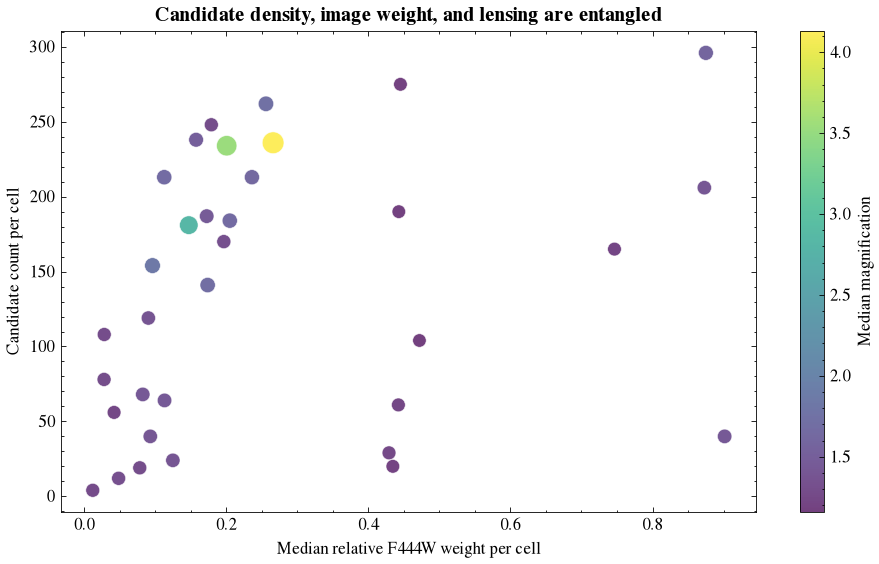

In [6]:
fig,ax=plt.subplots(figsize=(8,4.9)); sizes=25+35*np.clip(grid.median_mu,1,8)
sc=ax.scatter(grid.median_f444w_weight,grid.candidate_count,s=sizes,c=grid.median_mu,cmap="viridis",alpha=.75,edgecolor="white",linewidth=.4)
ax.set(xlabel="Median relative F444W weight per cell",ylabel="Candidate count per cell",title="Candidate density, image weight, and lensing are entangled")
fig.colorbar(sc,ax=ax,label="Median magnification"); fig.tight_layout(); fig.savefig("candidate_density_depth_relation.png"); plt.show()

In [7]:
FOLDER="2026-08-01-uncover-spatial-selection"; TITLE="Is the sky density of UNCOVER high-z candidates spatially uniform?"
QUESTION="Do candidate surface-density variations track F444W coverage and lensing structure?"; SAMPLE_SIZE=len(spatial)
RESULTS=[f"The 7x7 occupied-cell depth relation has Spearman rho = {rho:.2f} (p = {p:.3g})",f"Grid stress-test rho spans {stress.rho_count_weight.min():.2f} to {stress.rho_count_weight.max():.2f}"]
VALIDATION="The relation is repeated across five grid resolutions and is interpreted only as a selection diagnostic."
FIGURES=["highz_candidate_sky_map.png","candidate_density_depth_relation.png"]; ARTIFACTS=["spatial_grid_summary.csv","spatial_binning_sensitivity.csv"]
QUALITY_CHECKS=[{"name":"finite coordinate and weight cut","status":"passed"},{"name":"five grid resolutions","status":"passed"},{"name":"lensing shown explicitly","status":"passed"}]
LIMITATIONS=["Counts are not corrected by source-plane area or completeness.","A single cluster field cannot establish cosmic clustering."]

## References and next validation

- Suess et al. (2024), UNCOVER Data Release 3 photometric catalogue.
- Weaver et al. (2024), MegaScience and UNCOVER imaging catalogue methods.
- Bezanson et al. (2024), UNCOVER survey design and public data.
- Furtak et al. (2023), Abell 2744 lens model.
- Price et al. (2025), UNCOVER DR4/4.1 NIRSpec spectra and secure redshifts.

UNCOVER DR4.1 reports 409 secure or solid spectroscopic redshifts among 553
reduced targets and provides an updated v2.0 lens model. A strong follow-up is
to row-match the DR3 IDs to those products, remeasure the photometric-redshift
outlier rate, and replace approximate lens corrections used here. The notebook
is deliberately frozen to one internally consistent public photometric release
so that later comparisons are explicit rather than silently mixing versions.

In [8]:
record = {
    "id": FOLDER,
    "title": TITLE,
    "archive": "UNCOVER / MAST",
    "date": "2026-08-01",
    "question": QUESTION,
    "sample_size": int(SAMPLE_SIZE),
    "results": RESULTS,
    "validation": VALIDATION,
    "notebook": f"mast/{FOLDER}/notebook.ipynb",
    "hero": f"mast/{FOLDER}/{FIGURES[0]}",
    "figures": [f"mast/{FOLDER}/{name}" for name in FIGURES],
    "research_level": "Exploration",
    "claim_type": "Photometric candidate analysis",
    "provenance": [
        "UNCOVER DR3 SUPER catalog, Zenodo DOI 10.5281/zenodo.11059273",
        "Upstream MD5 baeb44ce166c920050ceb93220b12e05",
        "Selection: use_phot=1, flag_eazy=1, 6 <= z_phot < 15",
    ],
    "artifacts": [f"mast/{FOLDER}/{name}" for name in ARTIFACTS],
    "quality_checks": QUALITY_CHECKS,
    "limitations": LIMITATIONS,
}
Path("result.json").write_text(json.dumps(record, indent=2) + "\n")
print("Saved machine-readable scientific audit:", Path("result.json").resolve())

Saved machine-readable scientific audit: /workspace/scratch/20efe8222c82/daily-astro-stage9/mast/2026-08-01-uncover-spatial-selection/result.json
